In [1]:
import json
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
BASE = os.path.join(os.path.dirname(os.getcwd()), 'examples/comparisons/target=free_diiid_3_coil_06_10')
results_files = glob.glob(os.path.join(BASE, '**', 'results.json'), recursive=True)
print(f'{len(results_files)} results files')

28 results files


In [3]:
records = []
for fp in results_files:
    with open(fp) as f:
        d = json.load(f)
    s = d.get('optimization_settings', {})
    folder = os.path.relpath(fp, BASE)
    method_key = 'bayesian' if 'bayesian' in folder.lower() else 'lbfgs'
    for mname, m in d.get('methods', {}).items():
        flux_h = np.array([v if v is not None else np.nan for v in m.get('flux_err_history', [])])
        fb_h   = np.array([v if v is not None else np.nan for v in m.get('fb_cost_history', [])])
        records.append({
            'w': s.get('weight_fb'), 'c': s.get('num_coils'), 'method': method_key,
            'flux_h': flux_h, 'fb_h': fb_h,
            'n': len(flux_h),
            'init_fixed': m.get('initial_fixed_cost'),
            'init_fb': m.get('initial_fb_cost'),
            'best_flux': m.get('best_flux_err'),
            'best_fb': m.get('best_fb_cost'),
            'fb_failures': m.get('fb_failures', 0),
        })

print(f'{len(records)} records loaded')

28 records loaded


## Running-min flux_err and fb_cost vs eval

Shows how fast each component converges. This directly informs when ALPHA should start rising.

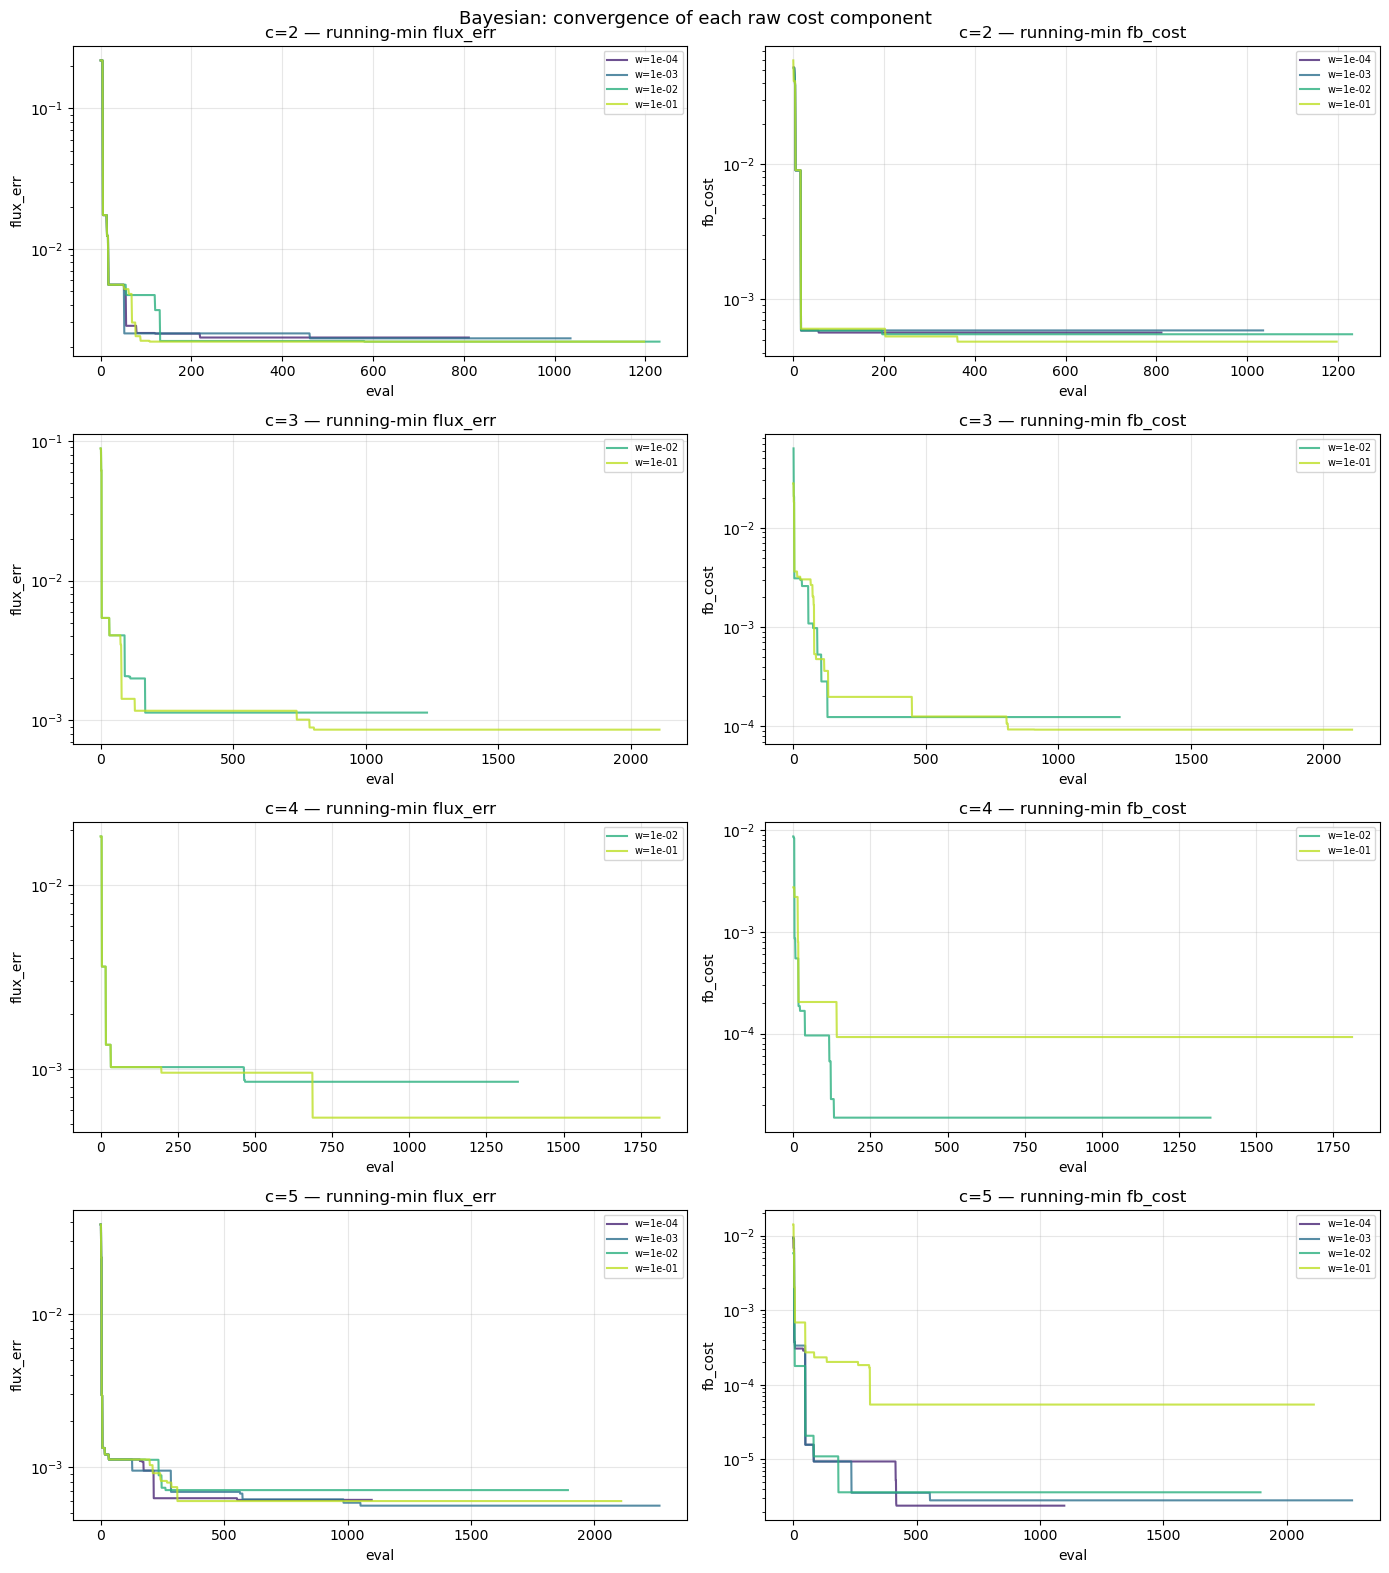

In [4]:
coils_list = sorted(set(r['c'] for r in records))
weights_list = sorted(set(r['w'] for r in records))
method_filter = 'bayesian'

fig, axes = plt.subplots(len(coils_list), 2, figsize=(14, 4*len(coils_list)), squeeze=False)
colors = cm.viridis(np.linspace(0.1, 0.9, len(weights_list)))

for row, c in enumerate(coils_list):
    ax_flux = axes[row, 0]
    ax_fb   = axes[row, 1]
    for w, col in zip(weights_list, colors):
        recs = [r for r in records if r['c'] == c and r['w'] == w and r['method'] == method_filter]
        for r in recs:
            flux_h = r['flux_h']
            fb_h   = r['fb_h']
            n = r['n']
            evals = np.arange(n)

            valid_flux = np.where(np.isnan(flux_h), np.inf, flux_h)
            run_min_flux = np.fmin.accumulate(valid_flux)
            run_min_flux[run_min_flux == np.inf] = np.nan
            ax_flux.semilogy(evals, run_min_flux, color=col, alpha=0.8, label=f'w={w:.0e}')

            valid_fb = np.where(np.isnan(fb_h) | (fb_h > 1e5), np.inf, fb_h)
            run_min_fb = np.fmin.accumulate(valid_fb)
            run_min_fb[run_min_fb == np.inf] = np.nan
            ax_fb.semilogy(evals, run_min_fb, color=col, alpha=0.8, label=f'w={w:.0e}')

    ax_flux.set_title(f'c={c} — running-min flux_err')
    ax_flux.set_xlabel('eval')
    ax_flux.set_ylabel('flux_err')
    ax_flux.legend(fontsize=7)
    ax_flux.grid(True, alpha=0.3)

    ax_fb.set_title(f'c={c} — running-min fb_cost')
    ax_fb.set_xlabel('eval')
    ax_fb.set_ylabel('fb_cost')
    ax_fb.legend(fontsize=7)
    ax_fb.grid(True, alpha=0.3)

plt.suptitle('Bayesian: convergence of each raw cost component', fontsize=13)
plt.tight_layout()
plt.show()

## When does flux_err stabilize?

Define stabilization as when running-min flux_err drops below 5x its final value.
This is the eval budget that should run at low ALPHA before we start ramping.

In [5]:
print(f'{'c':>3} {'w':>6} {'n':>6} {'stab_at':>8} {'stab_%':>8} {'best_flux':>12} {'best_fb':>12} {'fb_fail':>8}')
for c in coils_list:
    for w in weights_list:
        recs = [r for r in records if r['c'] == c and r['w'] == w and r['method'] == method_filter]
        for r in recs:
            flux_h = r['flux_h']
            n = r['n']
            valid = np.where(np.isnan(flux_h), np.inf, flux_h)
            run_min = np.fmin.accumulate(valid)
            final = run_min[-1]
            stab_idx = int(np.argmax(run_min < 5 * final)) if final < np.inf else n
            pct = stab_idx / n * 100
            bf = r['best_fb'] if r['best_fb'] is not None else float('nan')
            print(f"{c:>3} {w:>6.0e} {n:>6} {stab_idx:>8} {pct:>7.1f}% {r['best_flux']:>12.3e} {bf:>12.3e} {r['fb_failures']:>8}")

  c      w      n  stab_at   stab_%    best_flux      best_fb  fb_fail
  2  1e-04    812       17     2.1%    2.444e-03    5.646e-04      129
  2  1e-03   1036       17     1.6%    5.548e-03    5.859e-04       80
  2  1e-02   1232       17     1.4%    2.609e-03    5.487e-04      220
  2  1e-01   1198       17     1.4%    3.709e-03    4.835e-04       30
  3  1e-02   1232        4     0.3%    4.537e-03    1.238e-04      139
  3  1e-01   2109       33     1.6%    9.375e-04    9.243e-05       52
  4  1e-02   1353        4     0.3%    2.872e-03    1.495e-05       63
  4  1e-01   1812       17     0.9%    1.328e-03    9.264e-05       87
  5  1e-04   1099        4     0.4%    1.541e-03    9.382e-06      347
  5  1e-03   2265        7     0.3%    7.942e-04    2.828e-06      142
  5  1e-02   1894        4     0.2%    1.372e-03    3.626e-06      149
  5  1e-01   2110        4     0.2%    5.976e-04    5.431e-05       98


## Normalized cost ratio: norm_fb / norm_flux over evals

At each eval, compute the normalized components under alpha=1 (full free-boundary).
If `norm_fb >> norm_flux` early on, low ALPHA at start makes sense — fb noise drowns signal.

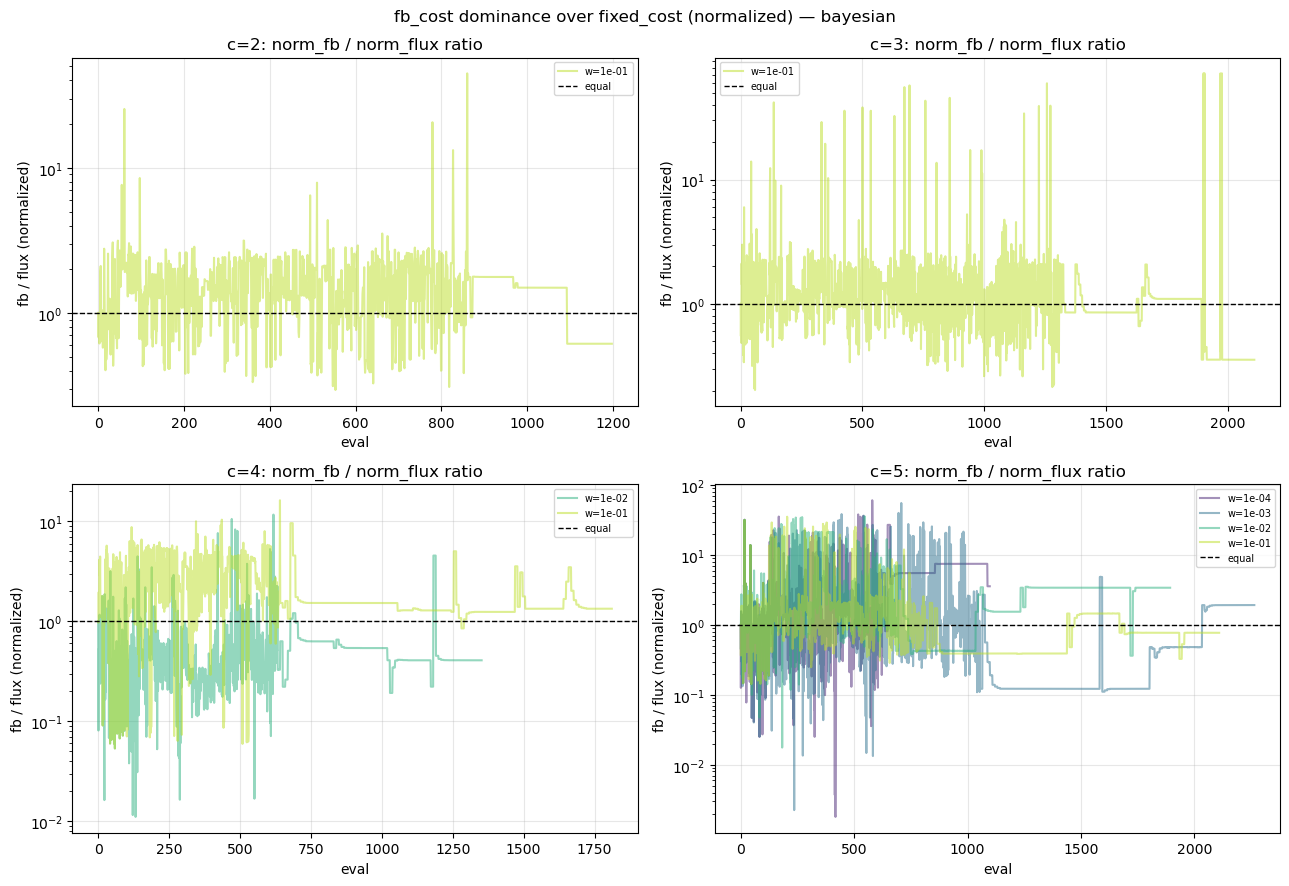

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, c in zip(axes, coils_list):
    for w, col in zip(weights_list, colors):
        recs = [r for r in records if r['c'] == c and r['w'] == w and r['method'] == method_filter]
        for r in recs:
            flux_h = r['flux_h']
            fb_h   = r['fb_h']
            if_c = r['init_fixed']
            if_b = r['init_fb']
            if if_c is None or if_b is None or if_b > 1e5:
                continue
            norm_flux = flux_h / if_c
            fb_valid = np.where((fb_h > 1e5) | np.isnan(fb_h), np.nan, fb_h)
            norm_fb  = fb_valid / if_b
            ratio = norm_fb / (norm_flux + 1e-30)
            valid_mask = ~np.isnan(ratio)
            evals = np.where(valid_mask)[0]
            ax.semilogy(evals, ratio[valid_mask], color=col, alpha=0.5, label=f'w={w:.0e}')
    ax.axhline(1.0, color='k', ls='--', lw=1, label='equal')
    ax.set_title(f'c={c}: norm_fb / norm_flux ratio')
    ax.set_xlabel('eval')
    ax.set_ylabel('fb / flux (normalized)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('fb_cost dominance over fixed_cost (normalized) — bayesian', fontsize=12)
plt.tight_layout()
plt.show()

## Alpha schedule candidates

Based on data above:
- Fixed boundary stabilizes within first ~5–25% of evals (often within the Sobol initial points)
- `n_initial = 25 * c` (e.g. 75 for c=3, 125 for c=5) sets the floor
- `BAYES_ITERS_PER_CHUNK = 50` so alpha bumps every 50 evals

Three candidate schedules (all use `ALPHA_MIN=0`, `ALPHA_MAX=1`):

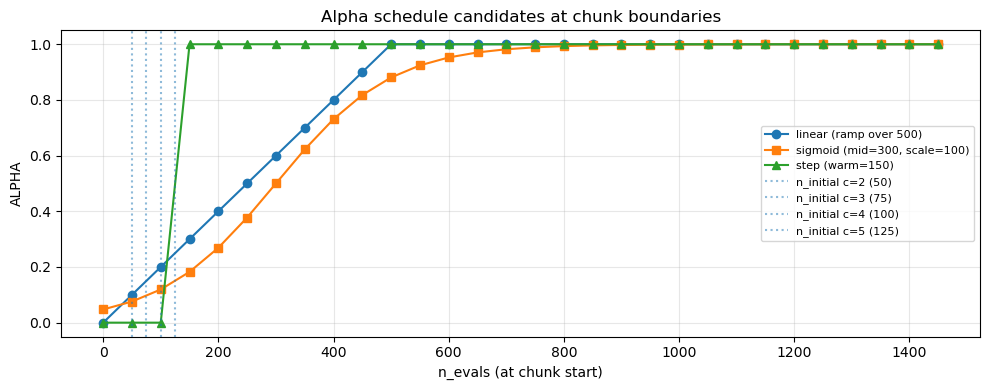

In [7]:
ALPHA_MIN = 0.0
ALPHA_MAX = 1.0
BAYES_ITERS_PER_CHUNK = 50

# Linear ramp: 0 -> 1 over RAMP_EVALS evaluations
RAMP_EVALS = 500
def alpha_linear(n):
    return ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * min(n / RAMP_EVALS, 1.0)

# Sigmoid centered at MID_EVAL, width SCALE
MID_EVAL = 300
SCALE = 100
def alpha_sigmoid(n):
    import math
    return ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) / (1 + math.exp(-(n - MID_EVAL) / SCALE))

# Step: ALPHA_MIN for first WARM_EVALS, then ALPHA_MAX
WARM_EVALS = 150  # ~3 chunks; covers n_initial for c<=5
def alpha_step(n):
    return ALPHA_MAX if n >= WARM_EVALS else ALPHA_MIN

# Show alpha at each chunk boundary
evals_axis = np.arange(0, 1500, BAYES_ITERS_PER_CHUNK)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(evals_axis, [alpha_linear(n) for n in evals_axis], 'o-', label=f'linear (ramp over {RAMP_EVALS})')
ax.plot(evals_axis, [alpha_sigmoid(n) for n in evals_axis], 's-', label=f'sigmoid (mid={MID_EVAL}, scale={SCALE})')
ax.plot(evals_axis, [alpha_step(n) for n in evals_axis], '^-', label=f'step (warm={WARM_EVALS})')

# mark n_initial for each coil count
for c in [2, 3, 4, 5]:
    ax.axvline(25*c, ls=':', alpha=0.5, label=f'n_initial c={c} ({25*c})')

ax.set_xlabel('n_evals (at chunk start)')
ax.set_ylabel('ALPHA')
ax.set_title('Alpha schedule candidates at chunk boundaries')
ax.legend(fontsize=8, loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## What would blended cost look like under each schedule?

For a representative run (bayesian, best weight), replay the history under each schedule
and show what the surrogate would have seen.

Representative: convergence_w5_bayesian/alpha:1.0,weight:1e-01,lambda:1e-06,coils:3/run_01/results.json
n=2109 init_fixed=8.850e-02 init_fb=0.028060577093320282


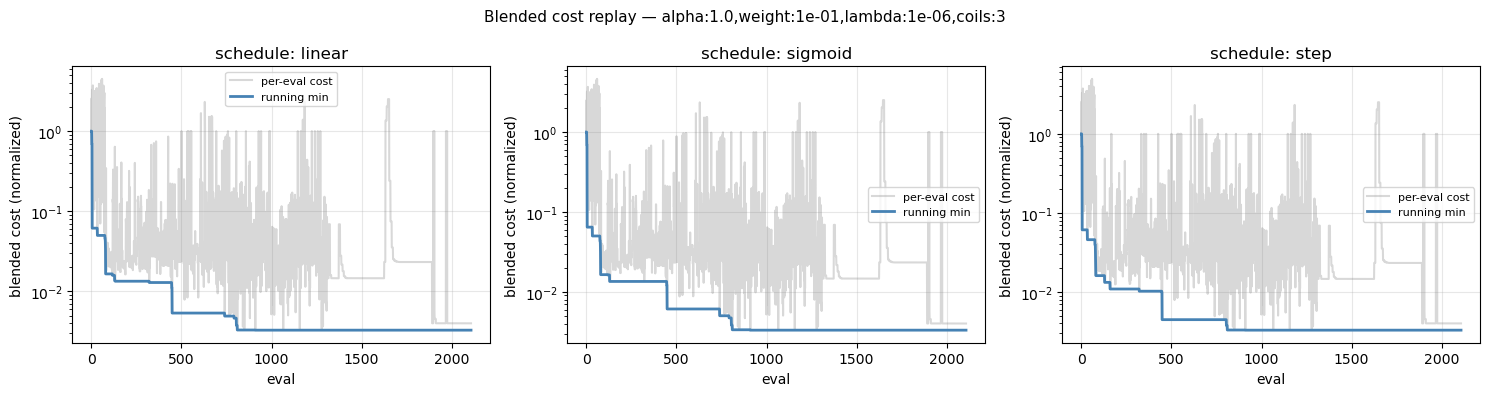

In [8]:
# pick c=3, best weight run
fp_rep = None
for fp in results_files:
    if 'coils:3' in fp and 'weight:1e-01' in fp and 'bayesian' in fp:
        fp_rep = fp
        break
if fp_rep is None:
    fp_rep = [f for f in results_files if 'coils:3' in f and 'bayesian' in f][0]

with open(fp_rep) as f:
    d = json.load(f)
m = list(d['methods'].values())[0]
flux_h = np.array([v if v is not None else np.nan for v in m['flux_err_history']])
fb_h   = np.array([v if v is not None else np.nan for v in m['fb_cost_history']])
if_c = m['initial_fixed_cost']
if_b = m['initial_fb_cost'] if m['initial_fb_cost'] and m['initial_fb_cost'] < 1e5 else None

print(f'Representative: {os.path.relpath(fp_rep, BASE)}')
print(f'n={len(flux_h)} init_fixed={if_c:.3e} init_fb={if_b}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
schedules = [
    ('linear',  alpha_linear),
    ('sigmoid', alpha_sigmoid),
    ('step',    alpha_step),
]

for ax, (name, sched) in zip(axes, schedules):
    blended = []
    for i in range(len(flux_h)):
        alpha = sched(i)
        fx = flux_h[i]
        fb = fb_h[i]
        if np.isnan(fx):
            blended.append(np.nan)
            continue
        nfx = fx / if_c if if_c else fx
        if np.isnan(fb) or fb > 1e5 or if_b is None:
            nfb = 1.0
        else:
            nfb = fb / if_b
        blended.append((1 - alpha) * nfx + alpha * nfb)
    blended = np.array(blended)
    run_min = np.fmin.accumulate(np.where(np.isnan(blended), np.inf, blended))
    run_min[run_min == np.inf] = np.nan
    ax.semilogy(blended, alpha=0.3, color='gray', label='per-eval cost')
    ax.semilogy(run_min, color='steelblue', lw=2, label='running min')
    ax.set_title(f'schedule: {name}')
    ax.set_xlabel('eval')
    ax.set_ylabel('blended cost (normalized)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Blended cost replay — {os.path.basename(os.path.dirname(os.path.dirname(fp_rep)))}', fontsize=11)
plt.tight_layout()
plt.show()

## Proposed schedule: long-bottom sigmoid + fb_failure boost

Two ideas:
1. **Convex bottom sigmoid** — shift midpoint right so the curve stays near 0 for the Sobol phase, then rises steeply. Parameterised by `MID` (eval at alpha=0.5) and `SCALE` (steepness).
2. **Failure-rate boost** — if `fb_failures / n_evals > FAILURE_RATE_TH`, add an additive lift so the GP penalises solver-crashing regions harder.

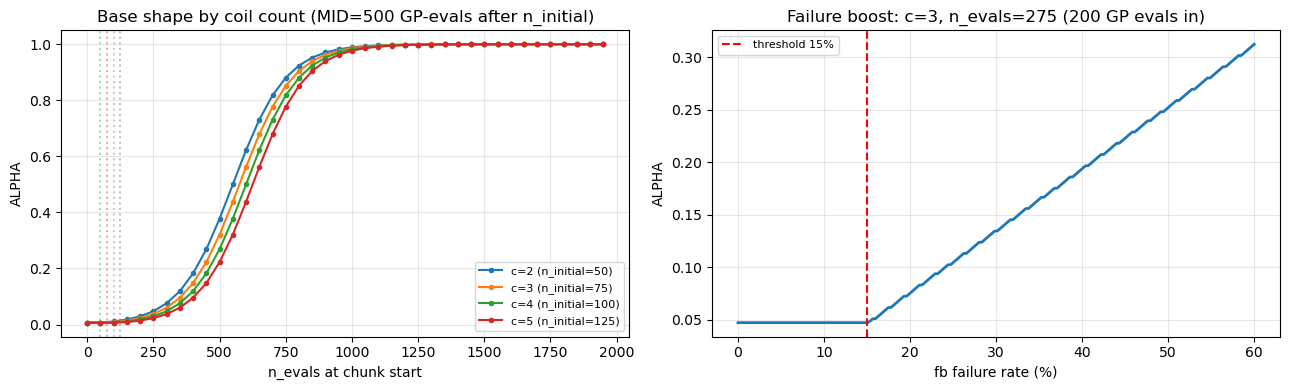

In [9]:
from math import exp

N_INITIAL_PER_COIL = 25  # matches opt_comp_comb_inc_alpha.py

# --- tunable parameters ---
MID   = 500    # GP-active evals where base sigmoid = 0.5 (indexed after n_initial)
SCALE = 100    # sigmoid steepness
FAILURE_RATE_TH = 0.15
FAILURE_BOOST   = 0.5

def alpha_proposed(n_evals, n_initial, fb_failures=0):
    gp_evals = max(n_evals - n_initial, 0)
    base = ALPHA_MAX / (1 + exp(-(gp_evals - MID) / SCALE))
    if n_evals >= n_initial:  # no boost during Sobol phase
        failure_rate = fb_failures / n_evals
        boost = FAILURE_BOOST * max(0.0, failure_rate - FAILURE_RATE_TH) / (1.0 - FAILURE_RATE_TH)
    else:
        boost = 0.0
    return min(base + boost, ALPHA_MAX)

# --- shape per coil count (no failures) ---
evals_axis = np.arange(0, 2000, BAYES_ITERS_PER_CHUNK)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for c in [2, 3, 4, 5]:
    n_init = N_INITIAL_PER_COIL * c
    ax.axvline(n_init, ls=':', alpha=0.4, color=f'C{c}')
    ax.plot(evals_axis, [alpha_proposed(n, n_init) for n in evals_axis],
            'o-', ms=3, label=f'c={c} (n_initial={n_init})')
ax.set_xlabel('n_evals at chunk start')
ax.set_ylabel('ALPHA')
ax.set_title(f'Base shape by coil count (MID={MID} GP-evals after n_initial)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- failure boost at n=n_initial+200 for c=3 ---
ax = axes[1]
c_test, n_test_offset = 3, 200
n_init_test = N_INITIAL_PER_COIL * c_test
n_test = n_init_test + n_test_offset
failure_rates = np.linspace(0, 0.6, 200)
alphas_fail = [alpha_proposed(n_test, n_init_test, int(fr * n_test)) for fr in failure_rates]
ax.plot(failure_rates * 100, alphas_fail, lw=2)
ax.axvline(FAILURE_RATE_TH * 100, ls='--', color='r', label=f'threshold {FAILURE_RATE_TH*100:.0f}%')
ax.set_xlabel('fb failure rate (%)')
ax.set_ylabel('ALPHA')
ax.set_title(f'Failure boost: c={c_test}, n_evals={n_test} ({n_test_offset} GP evals in)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

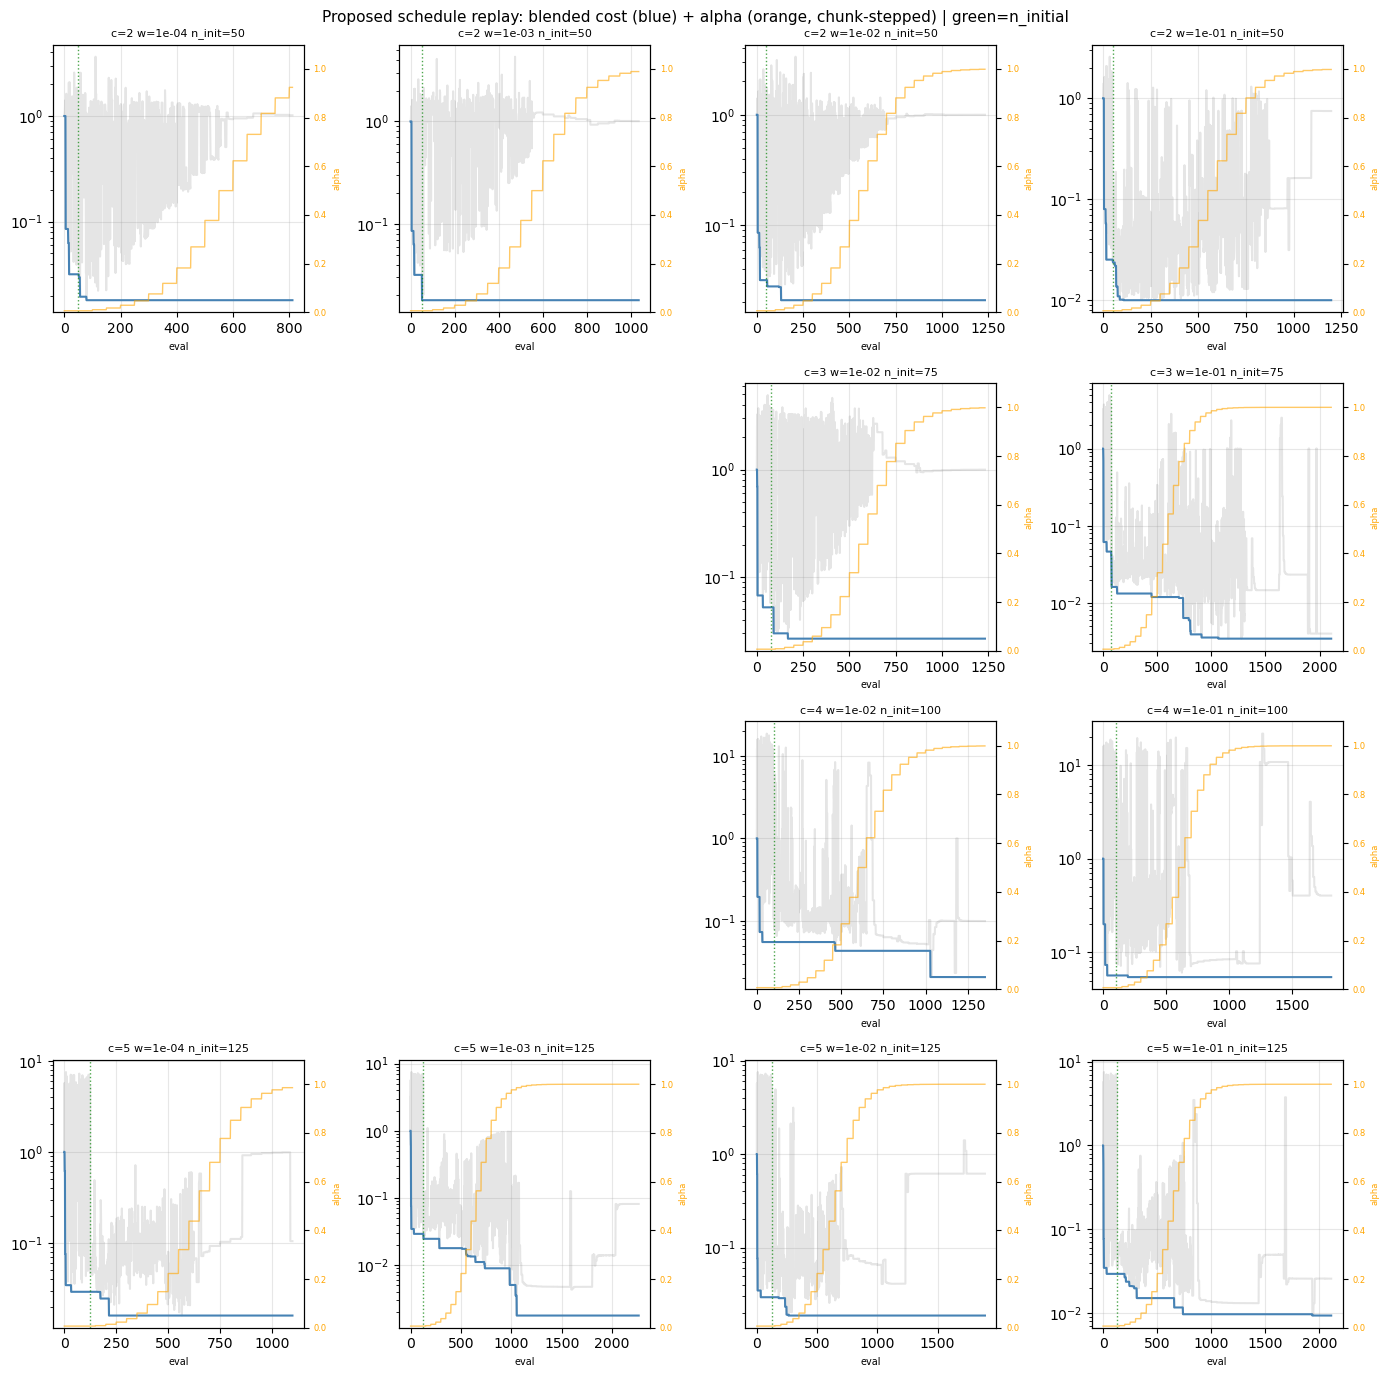

In [10]:
fig, axes = plt.subplots(len(coils_list), len(weights_list), figsize=(14, 3.5*len(coils_list)), squeeze=False)

for row, c in enumerate(coils_list):
    n_initial = N_INITIAL_PER_COIL * c
    for col, w in enumerate(weights_list):
        ax = axes[row, col]
        recs = [r for r in records if r['c'] == c and r['w'] == w and r['method'] == 'bayesian']
        if not recs:
            ax.set_visible(False)
            continue
        for r in recs:
            flux_h = r['flux_h']
            fb_h   = r['fb_h']
            if_c   = r['init_fixed']
            if_b   = r['init_fb'] if r['init_fb'] and r['init_fb'] < 1e5 else None
            n      = len(flux_h)
            cum_failures = np.cumsum((fb_h > 1e5) | np.isnan(fb_h))

            # alpha steps at chunk boundaries, constant within each chunk
            chunk_starts = np.arange(0, n, BAYES_ITERS_PER_CHUNK)
            alpha_at_chunk = {s: alpha_proposed(s, n_initial, int(cum_failures[s]))
                              for s in chunk_starts}

            blended, alphas_used = [], []
            for i in range(n):
                chunk_start = (i // BAYES_ITERS_PER_CHUNK) * BAYES_ITERS_PER_CHUNK
                alpha = alpha_at_chunk[chunk_start]
                alphas_used.append(alpha)
                fx = flux_h[i]
                fb = fb_h[i]
                if np.isnan(fx) or if_c is None:
                    blended.append(np.nan)
                    continue
                nfx = fx / if_c
                nfb = 1.0 if (np.isnan(fb) or fb > 1e5 or if_b is None) else fb / if_b
                blended.append((1 - alpha) * nfx + alpha * nfb)

            blended = np.array(blended)
            run_min = np.fmin.accumulate(np.where(np.isnan(blended), np.inf, blended))
            run_min[run_min == np.inf] = np.nan

            ax.semilogy(blended, alpha=0.2, color='gray')
            ax.semilogy(run_min, lw=1.5, color='steelblue')
            ax.axvline(n_initial, ls=':', color='green', lw=1, alpha=0.7)

            ax2 = ax.twinx()
            ax2.plot(alphas_used, color='orange', alpha=0.6, lw=1)
            ax2.set_ylim(0, 1.1)
            ax2.set_ylabel('alpha', fontsize=6, color='orange')
            ax2.tick_params(axis='y', labelcolor='orange', labelsize=6)

        ax.set_title(f'c={c} w={w:.0e} n_init={n_initial}', fontsize=8)
        ax.set_xlabel('eval', fontsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle('Proposed schedule replay: blended cost (blue) + alpha (orange, chunk-stepped) | green=n_initial', fontsize=11)
plt.tight_layout()
plt.show()

## Schedule vs fixed alpha=1: convergence comparison

**Caveat:** same eval locations for both — the schedule would change *which* points the GP proposes in a real run, which we can't simulate. What we can check: does the schedule's blended cost (varying alpha) track the true alpha=1 objective? If the running-mins align, the schedule is a good proxy. If they diverge, the schedule may mislead the surrogate into optimising the wrong thing early on.

Both curves show running-min of the blended cost evaluated at alpha=1 (true objective, blue) vs the schedule's own varying-alpha cost (orange). Alignment = schedule is a valid curriculum.